# The Genomic Time Machine: Authenticating Ancient DNA
Project 23 — analysis notebook. It **reads** the pipeline outputs in `results/` and does not recompute anything.
Regenerate the inputs with `snakemake -s workflow/Snakefile --cores 6`.

Sections: 1 data and provenance · 2 damage profiles · 3 verdicts · 4 fragment lengths (why not long reads) · 5 reference bias · 6 runtime

In [1]:
import json, os, pandas as pd, matplotlib.pyplot as plt
os.chdir(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else None
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
rows = [l.rstrip('\n').split('\t') for l in open('config/samples.tsv') if not l.startswith('#') and l.strip()]
meta = {r[0]: dict(runs=r[1], species=r[3], layout=r[5], protocol=r[6], expect=r[7]) for r in rows}
SAMPLES = list(meta)
STYLE = {'partial_udg': ('#ef8a62','-'), 'full_udg': ('#2166ac','--'), 'modern': ('#444444',':'), 'undeclared': (None,'-')}
PAL = ['#762a83', '#1b7837', '#d6604d', '#4393c3']
def style(name, k=[0]):
    c, ls = STYLE[meta[name]['protocol']]
    if c is None:
        c = PAL[hash(name) % len(PAL)]
    return dict(color=c, ls=ls, lw=1.8, label=f"{name} ({meta[name]['protocol']})")
pd.DataFrame(meta).T

,runs,species,layout,protocol,expect
TRP002.A,ERR3457840;ERR3457841,ypestis,SINGLE,partial_udg,terminal_only
LBG002.A,ERR3457603;ERR3457605,ypestis,SINGLE,full_udg,none
LVC005.A,ERR3341198;ERR3341197;ERR3341201;ERR3341200,ypestis,SINGLE,undeclared,unknown
LVC001.C,ERR3341142,ypestis,PAIRED,undeclared,unknown
LP31b,SRR1048901,ypestis,PAIRED,undeclared,unknown
MOD1953,SRR10259775,ypestis,PAIRED,modern,none
Motala1,ERR577492,human,SINGLE,undeclared,unknown


## 1. Data and provenance (task 2)
Every accession is fetched by `scripts/fetch_ena.py` with retry, resume and MD5 verification. The audit below counts which of seven structured archive fields are actually filled in.

In [2]:
prov = pd.read_csv('results/summary/provenance.tsv', sep='\t')
prov[['sample','run','collection_date','country','location','library_construction_protocol','completeness']]

,sample,run,collection_date,country,location,library_construction_protocol,completeness
0,TRP002.A,ERR3457840,(empty),(empty),(empty),Partial UDG-treatment,0.57
1,LBG002.A,ERR3457603,(empty),(empty),(empty),Full UDG-treatment,0.57
2,LVC005.A,ERR3341198,(empty),(empty),(empty),(empty),0.43
3,LVC001.C,ERR3341142,(empty),(empty),(empty),(empty),0.43
4,LP31b,SRR1048901,(empty),(empty),(empty),(empty),0.43
5,MOD1953,SRR10259775,1953-07-03,Russia: Chechnya,(empty),(empty),0.71
6,Motala1,ERR577492,(empty),(empty),(empty),(empty),0.43


**Reading it.** Date, country and location are empty for every ancient sample; the archaeological context lives in the papers, not the archive. The library protocol, which decides what damage to expect, is declared for only 2 of 7. The only record with a date and country is the modern isolate MOD1953 (1953-07-03, Chechnya).

## 2. Damage profiles (task 7)
Deamination turns C into U, read as T. It is fastest in the single-stranded overhangs at fragment ends, so the signal is a C→T spike at the 5′ end and G→A at the 3′ end that decays inward.

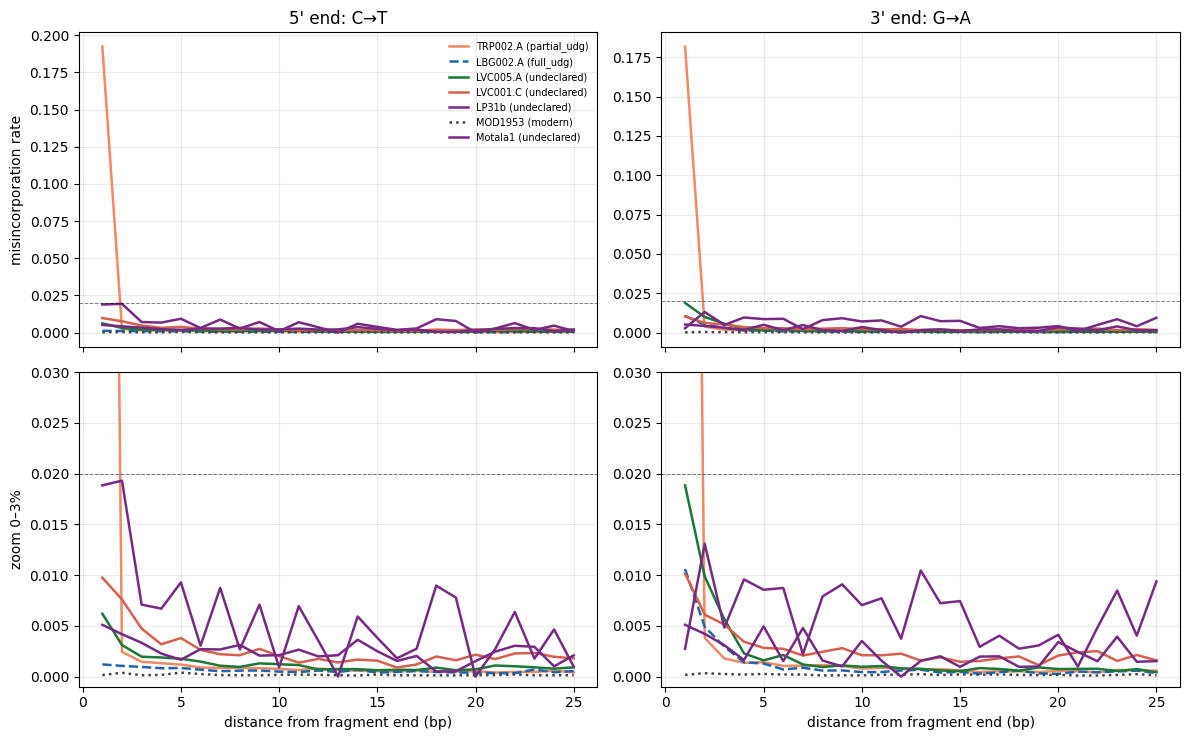

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True)
for n in SAMPLES:
    d = json.load(open(f'results/damage/{n}.json')); st = style(n)
    for r, ymax in enumerate((None, 0.03)):
        ax[r][0].plot([x['position'] for x in d['profile_5p']], [x['C>T'] for x in d['profile_5p']], **st)
        ax[r][1].plot([x['position'] for x in d['profile_3p']], [x['G>A'] for x in d['profile_3p']], **st)
for r, ymax in enumerate((None, 0.03)):
    for c in (0, 1):
        ax[r][c].axhline(0.02, color='k', lw=.7, ls='--', alpha=.5); ax[r][c].grid(alpha=.25)
        if ymax: ax[r][c].set_ylim(-0.001, ymax)
ax[0][0].set_title("5' end: C→T"); ax[0][1].set_title("3' end: G→A")
ax[0][0].set_ylabel('misincorporation rate'); ax[1][0].set_ylabel('zoom 0–3%')
ax[1][0].set_xlabel('distance from fragment end (bp)'); ax[1][1].set_xlabel('distance from fragment end (bp)')
ax[0][0].legend(fontsize=7, frameon=False); plt.tight_layout(); plt.show()

**How to read this plot.** X axis: distance from the fragment end (1 = last base). Y axis: share of bases that differ from the reference (0.19 = 19%). Left: 5' end, C to T. Right: 3' end, G to A. Top row is full scale, bottom row is zoomed to 0-3%.
* TRP002.A (orange): about 19% at the first base, then drops to near zero. Damage concentrated at the end, so the sample is ancient.
* MOD1953 (grey dotted): flat at zero. Modern isolate, used as the negative control.
* LBG002.A (blue dashed): near zero although the sample is ancient. It was UDG-treated, which removes the damage.
* Other lines (protocol not declared): weak and noisy, no clear call.
* Dashed horizontal line: the 0.02 threshold.

**Reading it.** TRP002.A spikes to ~19% at the terminal base and falls to ~0.2% at the second: damage confined to one base is the signature of **partial UDG**, so the profile shape reports the lab protocol. The modern control MOD1953 is flat at ~0.0002.

In [4]:
# The A>G control: deamination cannot produce it, so a terminal rise means an artefact, not damage.
out = []
for n in SAMPLES:
    s = json.load(open(f'results/damage/{n}.json'))['summary']
    out.append(dict(sample=n, ct_5p_terminal=s['ct_5p']['terminal'], ct_5p_interior=s['ct_5p']['interior_background'],
                    ct_5p_excess=s['ct_5p']['delta'], ga_3p_excess=s['ga_3p']['delta'], control_ag_excess=s['ag_5p_control']['delta'],
                    enrichment=round(s['ct_5p']['terminal'] / max(s['ct_5p']['interior_background'], 1e-9))))
pd.DataFrame(out).round(4)

,sample,ct_5p_terminal,ct_5p_interior,ct_5p_excess,ga_3p_excess,control_ag_excess,enrichment
0,TRP002.A,0.1924,0.0005,0.1918,0.1811,0.0032,356
1,LBG002.A,0.0012,0.0005,0.0007,0.0101,0.0028,3
2,LVC005.A,0.0062,0.0008,0.0054,0.0181,0.0072,8
3,LVC001.C,0.0097,0.0017,0.0080,0.0083,0.0094,6
4,LP31b,0.0188,0.0039,0.0150,-0.0027,0.0112,5
5,MOD1953,0.0001,0.0001,0.0000,-0.0000,0.0015,1
6,Motala1,0.0051,0.0020,0.0031,0.0034,0.0035,3


**How to read the table above.** `ct_5p_excess` is the first-base C to T rate minus the interior rate (positions 11-25), so a library with errors everywhere does not pass on error alone. `enrichment` is terminal rate divided by interior rate. `control_ag_excess` is A to G at the end: deamination cannot produce it, so a rise means an artefact.

## 3. Verdicts (tasks 7 and 8)

In [5]:
t = pd.read_csv('results/summary/authentication_table.tsv', sep='\t')
t[['sample','protocol','verdict','ct_5p_delta','ga_3p_delta','control_ag_delta','endogenous_fraction','frag_median']].round(4)

,sample,protocol,verdict,ct_5p_delta,ga_3p_delta,control_ag_delta,endogenous_fraction,frag_median
0,TRP002.A,partial_udg,ANCIENT,0.1918,0.1811,0.0032,0.2329,42.0
1,LBG002.A,full_udg,UDG_TREATED_RESIDUAL_SIGNAL,0.0007,0.0101,0.0028,0.3198,56.0
2,LVC005.A,undeclared,WEAK_ANCIENT_SIGNAL,0.0054,0.0181,0.0072,0.1834,53.0
3,LVC001.C,undeclared,NO_DAMAGE_DETECTED,0.0080,0.0083,0.0094,0.0699,43.0
4,LP31b,undeclared,UNRELIABLE,0.0150,-0.0027,0.0112,0.0246,49.0
5,MOD1953,modern,MODERN_AS_EXPECTED,0.0000,-0.0000,0.0015,0.9472,305.0
6,Motala1,undeclared,NO_DAMAGE_DETECTED,0.0031,0.0034,0.0035,0.0011,54.0


In [6]:
print(open('results/summary/authentication_report.md').read().split('## Reasoning')[1][:4000])



**TRP002.A** (partial_udg) - ANCIENT  
terminal C>T excess +0.1918 and G>A excess +0.1811 both clear 0.02, they agree within 1.1x, and the control stays flat at +0.0032

**LBG002.A** (full_udg) - UDG_TREATED_RESIDUAL_SIGNAL  
3' G>A excess +0.0101 decays monotonically from the terminus (5' C>T 0.0012, 0.0011, 0.0010; 3' G>A 0.0106, 0.0049, 0.0030) with the control flat at +0.0028. A small residual after full UDG treatment is expected, since the enzyme does not excise every uracil, so this is not evidence against the treatment having worked

**LVC005.A** (undeclared) - WEAK_ANCIENT_SIGNAL  
3' G>A excess +0.0181 decays monotonically from the terminus (5' C>T 0.0062, 0.0031, 0.0020; 3' G>A 0.0188, 0.0099, 0.0057) with the control flat at +0.0072; below the strong threshold (0.02) but far above the noise floor and damage-shaped. Consistent with a partly UDG-treated or well-preserved library, or with a modest ancient fraction diluted by modern DNA; damage alone cannot say which

**LVC001

**How to read the verdict table.** ANCIENT: strong damage at both ends. MODERN_AS_EXPECTED: no damage in the modern control. UDG_TREATED_RESIDUAL_SIGNAL: UDG-treated, cannot be tested by damage. WEAK_ANCIENT_SIGNAL: small decaying signal. NO_DAMAGE_DETECTED: ambiguous, protocol undeclared. UNRELIABLE: the A to G control rose. Do not compare `endogenous_fraction` across rows: two samples are capture-enriched and Motala1 was mapped to mtDNA only.

**Did the estimator behave?** Yes on both controls: silent on the modern isolate, fires on the declared-damage library. Caveats worth stating:
* *Endogenous fractions are not comparable across rows.* TRP002.A and LBG002.A are **targeted-capture** libraries (enriched), and Motala1 is a human shotgun library mapped to the **mitochondrion only**.
* `LP31b` is *UNRELIABLE*: its A→G control rises on only ~4.6k usable reads, so the honest output is "not enough data".
* `WEAK_ANCIENT_SIGNAL` (LVC005.A) is a tier added **after** seeing the data, justified by the modern control's noise floor (~0.0002) being >50× below 0.01.

## 4. Fragment lengths: why long reads do not apply (task 5)

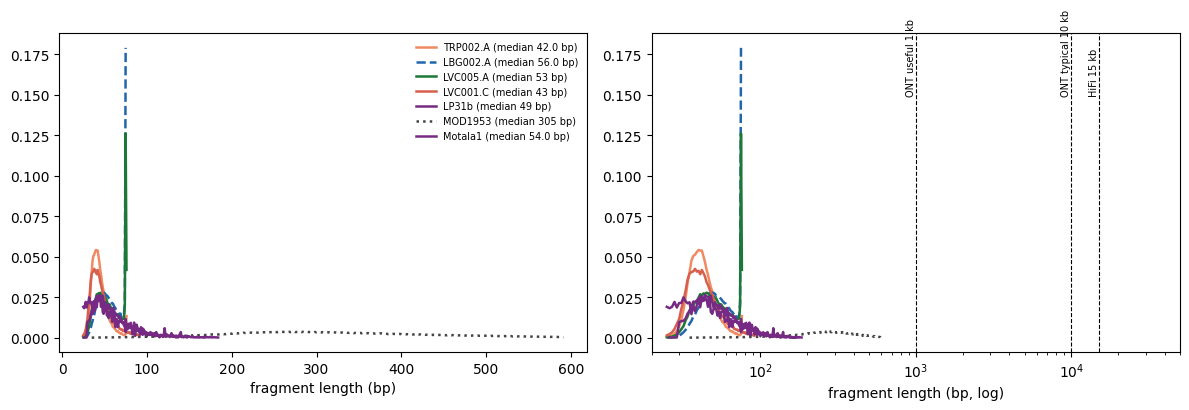

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for n in SAMPLES:
    d = json.load(open(f'results/lengths/{n}.json')); h = {int(k): v for k, v in d['histogram'].items()}; tot = sum(h.values())
    xs = sorted(h); ys = [h[x] / tot for x in xs]; st = style(n); st['label'] = f"{n} (median {d['median']} bp)"
    ax[0].plot(xs, ys, **st); ax[1].plot(xs, ys, **st)
ax[1].set_xscale('log'); ax[1].set_xlim(20, 50000)
for x, l in [(1000, 'ONT useful 1 kb'), (10000, 'ONT typical 10 kb'), (15000, 'HiFi 15 kb')]:
    ax[1].axvline(x, color='k', ls='--', lw=.8); ax[1].text(x, ax[1].get_ylim()[1] * .8, l, rotation=90, ha='right', fontsize=7)
ax[0].set_xlabel('fragment length (bp)'); ax[1].set_xlabel('fragment length (bp, log)'); ax[0].legend(fontsize=7, frameon=False)
plt.tight_layout(); plt.show()

In [8]:
rows = []
for n in SAMPLES:
    d = json.load(open(f'results/lengths/{n}.json'))
    rows.append(dict(sample=n, n=d['n'], median=d['median'], p95=d['p95'], longest=d['max'],
                     frac_ge_1kb=d['fraction_above_platform_threshold']['ONT_useful_1kb'],
                     right_censored_at_cap=round(d['fraction_at_max_length_right_censored'], 3)))
pd.DataFrame(rows)

,sample,n,median,p95,longest,frac_ge_1kb,right_censored_at_cap
0,TRP002.A,1312882,42.0,63,76,0.0,0.013
1,LBG002.A,248802,56.0,75,75,0.0,0.179
2,LVC005.A,147349,53.0,75,76,0.0,0.042
3,LVC001.C,151585,43.0,73,91,0.0,0.001
4,LP31b,4617,49.0,105,149,0.0,0.001
5,MOD1953,513605,305.0,518,591,0.0,0.000
6,Motala1,8928,54.0,111,184,0.0,0.000


**How to read this plot.** X axis: fragment length in bases (right panel is log scale). Y axis: share of fragments with that length. Dashed vertical lines mark 1 kb, 10 kb and 15 kb, where long-read platforms start to help.
* All ancient samples sit at about 40-60 bases; none reaches the dashed lines.
* The modern control is longer (about 300 bases).
* The sharp spike at 75-76 is not real: it is the read-length cap (right-censoring).

**Reading it.** No fragment of 2.4 M ancient fragments reaches 1 kb (median 42–56 bp), so long-read platforms have nothing to read. The spike at 75–76 bp is **right-censoring** by the read cycle count, not a real mode (17.9% of LBG002.A), so "longest" is a lower bound there. The modern control at 305 bp is still two orders of magnitude below the long-read regime because it was sequenced as short-insert Illumina.

The second argument (error rate) is only sample-dependent: TRP002.A's 19% signal is 3.8× ONT error, so a strongly damaged library would still be detectable in principle, while the weak libraries (0.5–2%) are not.

## 5. Reference bias under permissive alignment (task 6)
Hypothesis: strict alignment discards deaminated reads. The first metric (damaged-read fraction among rescued reads) looked like confirmation but is **invalid**: it gave ~123× for the modern control, because reads rescued by permissive alignment carry extra mismatches of *any* kind. The valid test is the share of terminal mismatches that are damage-type.

In [9]:
rows = []
for n in SAMPLES:
    d = json.load(open(f'results/refbias/{n}.json'))
    rows.append(dict(sample=n, extra_yield_pct=round(100 * (d['extra_yield_fraction'] or 0), 1),
                     old_confounded_enrichment=round(d['damage_enrichment_in_recovered_reads'] or 0, 1),
                     damage_share_rescued=d['damage_type_share_of_terminal_mismatches_recovered'],
                     damage_share_both=d['damage_type_share_of_terminal_mismatches_shared'],
                     n_term_mm_rescued=d['terminal_mismatches_recovered']))
rb = pd.DataFrame(rows).round(3); rb

,sample,extra_yield_pct,old_confounded_enrichment,damage_share_rescued,damage_share_both,n_term_mm_rescued
0,TRP002.A,1.5,0.9,0.104,0.821,14140
1,LBG002.A,1.0,8.2,0.059,0.097,1533
2,LVC005.A,2.0,8.1,0.084,0.134,2098
3,LVC001.C,5.9,15.1,0.078,0.103,5738
4,LP31b,14.9,5.2,0.044,0.070,527
5,MOD1953,-1.1,123.1,0.065,0.057,214
6,Motala1,0.4,15.2,0.182,0.204,11


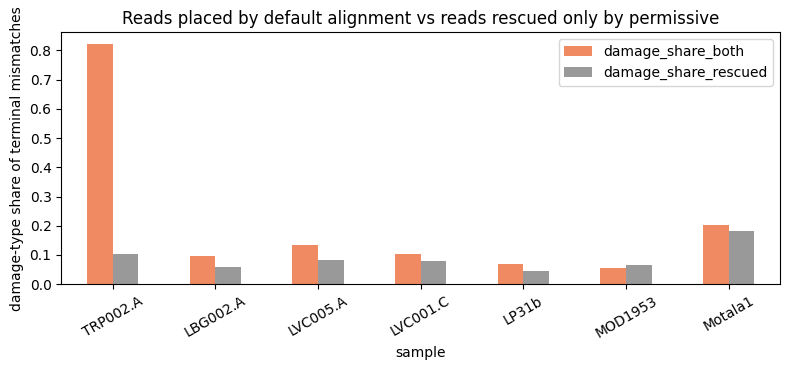

In [10]:
x = rb.set_index('sample')[['damage_share_both', 'damage_share_rescued']].dropna()
x.plot.bar(figsize=(8, 3.8), color=['#ef8a62', '#999999']); plt.ylabel('damage-type share of terminal mismatches')
plt.title('Reads placed by default alignment vs reads rescued only by permissive'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

**How to read these bars.** Y axis: share of terminal mismatches that are damage-type (C to T or G to A). Orange: reads that default alignment already places. Grey: reads added only by permissive alignment. In TRP002.A the orange bar is 82% and the grey bar is 10%, so default alignment was not losing the damaged reads. The modern control sits near 6%, the chance level. `old_confounded_enrichment` is the earlier metric we dropped: it gave 123x on the modern control, so it did not measure damage.

**Reading it.** In TRP002.A, **82%** of terminal mismatches in reads that default alignment already places are damage-type, but only **10%** in the rescued reads — near the modern control's chance level (~6%). Default alignment is **not** discarding deaminated molecules here: partial-UDG damage is a single terminal base, within default tolerance. The extra reads are divergent or erroneous. We could not test non-UDG libraries (no confirmed non-UDG sample), so this does not rule out bias elsewhere.

## 6. Runtime and memory

In [11]:
rt = pd.read_csv('results/summary/runtime.tsv', sep='\t')
rt.pivot(index='sample', columns='step', values='wall_seconds')

step,align_permissive,align_strict,authenticate,damage,lengths,reference_bias,trim
sample,,,,,,,
LBG002.A,35.6,5.2,4.6,5.5,0.8,9.4,0.8
LP31b,7.8,1.4,0.6,0.4,0.3,0.7,0.7
LVC001.C,100.0,15.2,6.9,5.0,2.5,9.7,3.5
LVC005.A,43.2,5.3,3.5,3.6,0.9,6.2,1.1
MOD1953,141.6,13.8,34.0,39.6,1.0,71.4,3.9
Motala1,37.6,40.2,14.0,6.7,5.7,13.8,7.1
TRP002.A,229.4,30.3,22.8,25.8,4.5,45.4,5.0


In [12]:
before = pd.read_csv('results/summary/runtime_before_optimisation.tsv', sep='\t')
after = rt
m = before.merge(after, on=['step', 'sample'], suffixes=('_before', '_after'))
m = m[m.step.isin(['damage', 'authenticate', 'reference_bias'])].copy()
m['speedup'] = (m.wall_seconds_before / m.wall_seconds_after).round(1)
m[m['sample'].isin(['MOD1953', 'TRP002.A'])][['step', 'sample', 'wall_seconds_before', 'wall_seconds_after', 'speedup']]

,step,sample,wall_seconds_before,wall_seconds_after,speedup
18,authenticate,MOD1953,154.3,34.0,4.5
20,authenticate,TRP002.A,64.1,22.8,2.8
25,damage,MOD1953,129.8,39.6,3.3
27,damage,TRP002.A,57.7,25.8,2.2
39,reference_bias,MOD1953,314.5,71.4,4.4
41,reference_bias,TRP002.A,120.2,45.4,2.6


In [13]:
print(open('results/summary/memory.tsv').read())

step	input	peak_rss
adapterremoval3 trim	TRP002.A (6.7M reads)	63 MB
bwa aln (permissive)	TRP002.A (1.1M reads)	804 MB
damage_profile.py	TRP002.A (1.3M mapped)	30 MB
damage_profile.py	MOD1953 (0.5M mapped)	32 MB



**How to read the timing tables.** `speedup` is time before divided by time after the optimisation; output was byte-identical. `memory.tsv` gives peak memory: our scripts 30-63 MB, `bwa aln` 804 MB.

**Reading it.** Profiling showed cost scaled with *bases* (one reference lookup per base); fetching the reference once per read gave 3–5× speedups with byte-identical output. Our streamed scripts use ~30–63 MB; permissive `bwa aln` peaks at ~804 MB and is the real scale limit. Snakemake's own memory column is `NA` on macOS, so memory was measured with `/usr/bin/time -l`. The 70 GB Ust'-Ishim genome was **not** processed.

## 7. Limitations
UDG-treated libraries cannot be authenticated by damage · protocol undeclared for 5 of 7 samples, so "no damage" is ambiguous · thresholds (0.02 / 0.01) are design choices and the weak tier is post hoc · LP31b and Motala1 are underpowered · no validated contamination percentage (`d_ref` is invalid under partial UDG; no X-chromosome/mtDNA-haplotype test) · a single modern control does not bound the false-positive rate · CO92 is a modern reference · duplicates not marked · Dockerfile not built.